In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("Nassau Candy Distributor.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  object 
 2   Order Date      10194 non-null  object 
 3   Ship Date       10194 non-null  object 
 4   Ship Mode       10194 non-null  object 
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  object 
 7   City            10194 non-null  object 
 8   State/Province  10194 non-null  object 
 9   Postal Code     10194 non-null  object 
 10  Division        10194 non-null  object 
 11  Region          10194 non-null  object 
 12  Product ID      10194 non-null  object 
 13  Product Name    10194 non-null  object 
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null 

In [ ]:
df = df[df['Sales'] > 0]

df['Units'] = df['Units'].fillna(df['Units'].median())

df['Division'] = df['Division'].str.strip()
df['Product Name'] = df['Product Name'].str.strip()

In [ ]:
df['Gross Margin %'] = (df['Gross Profit'] / df['Sales']) * 100

df['Profit Per Unit'] = df['Gross Profit'] / df['Units']

total_sales = df['Sales'].sum()
total_profit = df['Gross Profit'].sum()

df['Revenue Contribution %'] = (df['Sales'] / total_sales) * 100

df['Profit Contribution %'] = (df['Gross Profit'] / total_profit) * 100

In [ ]:
df.to_csv("clean_nassau.csv", index=False)

In [ ]:
product_profit = df.groupby('Product Name').agg({
    'Sales':'sum',
    'Gross Profit':'sum',
    'Gross Margin %':'mean',
    'Profit Per Unit':'mean'
}).reset_index()

product_profit.sort_values(
    'Gross Profit',
    ascending=False
)

,Product Name,Sales,Gross Profit,Gross Margin %,Profit Per Unit
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.444444,2.50
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.333333,2.45
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,64.923077,2.11
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.346705,2.49
9,Wonka Bar - Fudge Mallows,24890.40,16593.60,66.666667,2.40
6,Lickable Wallpaper,7860.00,3930.00,50.000000,10.00
14,Wonka Gum,597.50,310.70,52.000000,0.65
0,Everlasting Gobstopper,130.00,104.00,80.000000,8.00
4,Kazookles,1205.75,92.75,7.692308,0.25
3,Hair Toffee,76.50,59.50,77.777778,3.50


In [ ]:
division_analysis = df.groupby('Division').agg({
    'Sales':'sum',
    'Gross Profit':'sum',
    'Gross Margin %':'mean'
}).reset_index()

division_analysis

,Division,Sales,Gross Profit,Gross Margin %
0,Chocolate,131692.90,88824.62,67.458162
1,Other,9663.25,4333.45,37.672457
2,Sugar,427.48,284.73,57.689001


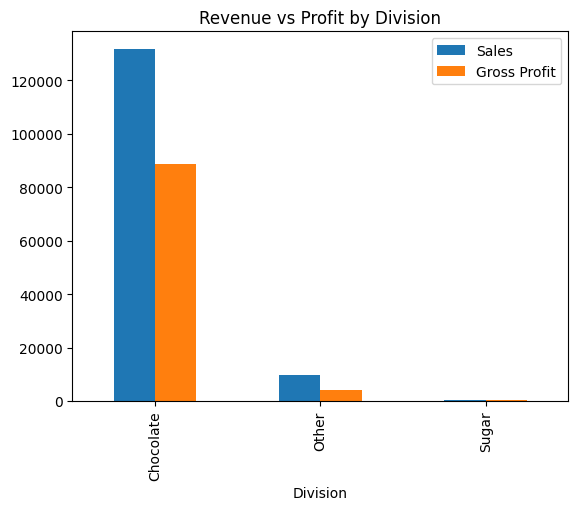

In [ ]:
import matplotlib.pyplot as plt

division_analysis.plot(
    x='Division',
    y=['Sales','Gross Profit'],
    kind='bar'
)

plt.title('Revenue vs Profit by Division')
plt.show()

In [ ]:
pareto = product_profit.sort_values(
    'Gross Profit',
    ascending=False
)

pareto['Cumulative Profit'] = pareto[
    'Gross Profit'
].cumsum()

pareto['Cumulative %'] = (
    pareto['Cumulative Profit']
    /
    pareto['Gross Profit'].sum()
)*100

In [ ]:
pareto[pareto['Cumulative %'] <= 80]

,Product Name,Sales,Gross Profit,Gross Margin %,Profit Per Unit,Cumulative Profit,Cumulative %
13,Wonka Bar -Scrumdiddlyumptious,27874.80,19357.50,69.444444,2.50,19357.50,20.715882
12,Wonka Bar - Triple Dazzle Caramel,28485.00,18610.20,65.333333,2.45,37967.70,40.632023
10,Wonka Bar - Milk Chocolate,26867.75,17443.37,64.923077,2.11,55411.07,59.299454
11,Wonka Bar - Nutty Crunch Surprise,23574.95,16819.95,71.346705,2.49,72231.02,77.299717


In [ ]:
df['Cost Ratio'] = (
    df['Cost']
    /
    df['Sales']
)*100

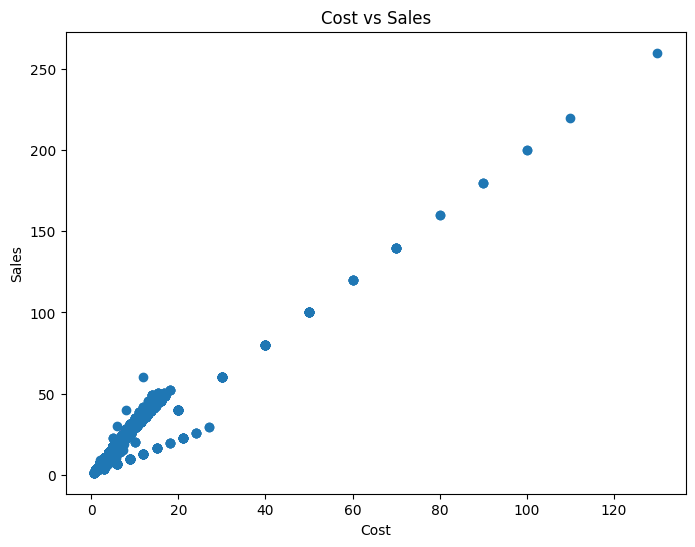

In [ ]:
plt.figure(figsize=(8,6))

plt.scatter(
    df['Cost'],
    df['Sales']
)

plt.xlabel('Cost')
plt.ylabel('Sales')
plt.title('Cost vs Sales')
plt.show()

In [ ]:
risk_products = df[
    (df['Gross Margin %'] < 40)
]

risk_products[
    ['Product Name','Sales','Gross Margin %']
]

,Product Name,Sales,Gross Margin %
26,Kazookles,9.75,7.692308
92,Kazookles,13.00,7.692308
160,Kazookles,19.50,7.692308
200,Kazookles,9.75,7.692308
210,Kazookles,13.00,7.692308
...,...,...,...
9259,Kazookles,9.75,7.692308
9357,Kazookles,13.00,7.692308
9699,Kazookles,9.75,7.692308
9859,Kazookles,3.25,7.692308


In [ ]:
top10 = product_profit.sort_values(
    'Gross Profit',
    ascending=False
).head(10)

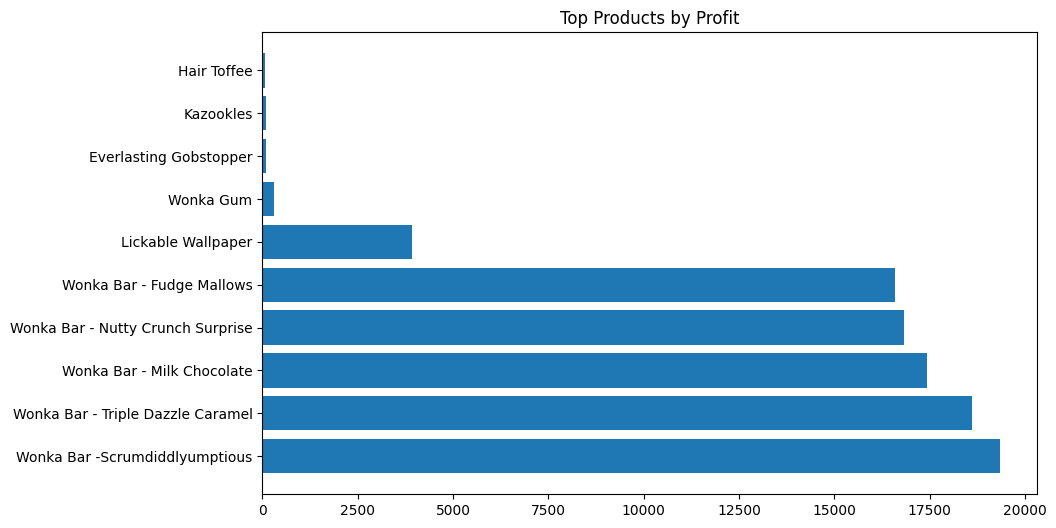

In [ ]:
plt.figure(figsize=(10,6))

plt.barh(
    top10['Product Name'],
    top10['Gross Profit']
)

plt.title('Top Products by Profit')
plt.show()

In [ ]:
!pip install streamlit plotly -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 57.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 86.8 MB/s eta 0:00:00


In [5]:
%%writefile app.py

import streamlit as st
import pandas as pd
import plotly.express as px

st.set_page_config(
    page_title="Nassau Candy Dashboard",
    layout="wide"
)

st.title("🍫 Nassau Candy Profitability Dashboard")

df = pd.read_csv("clean_nassau.csv")

# Sidebar Filters
st.sidebar.header("Filters")

division = st.sidebar.selectbox(
    "Division",
    ["All"] + list(df["Division"].unique())
)

margin = st.sidebar.number_input(
    "Minimum Margin %",
    min_value=0,
    max_value=100,
    value=0
)

product_search = st.sidebar.text_input(
    "Search Product"
)

filtered_df = df.copy()

if division != "All":
    filtered_df = filtered_df[
        filtered_df["Division"] == division
    ]

if product_search:
    filtered_df = filtered_df[
        filtered_df["Product Name"]
        .str.contains(product_search, case=False)
    ]

filtered_df = filtered_df[
    filtered_df["Gross Margin %"] >= margin
]

# KPI Cards
c1,c2,c3 = st.columns(3)

c1.metric(
    "Total Sales",
    f"${filtered_df['Sales'].sum():,.0f}"
)

c2.metric(
    "Total Profit",
    f"${filtered_df['Gross Profit'].sum():,.0f}"
)

c3.metric(
    "Average Margin",
    f"{filtered_df['Gross Margin %'].mean():.2f}%"
)

# Product Profitability
st.subheader("Top 10 Products by Profit")

product_profit = (
    filtered_df.groupby("Product Name")
    ["Gross Profit"]
    .sum()
    .reset_index()
)

product_profit = product_profit.sort_values(
    "Gross Profit",
    ascending=False
).head(10)

fig = px.bar(
    product_profit,
    x="Gross Profit",
    y="Product Name",
    orientation="h"
)

st.plotly_chart(fig, use_container_width=True)

# Division Analysis
st.subheader("Division Performance")

division_data = (
    filtered_df.groupby("Division")
    [["Sales","Gross Profit"]]
    .sum()
    .reset_index()
)

fig = px.bar(
    division_data,
    x="Division",
    y=["Sales","Gross Profit"],
    barmode="group"
)

st.plotly_chart(fig, use_container_width=True)

# Cost Diagnostics
st.subheader("Cost vs Sales")

fig = px.scatter(
    filtered_df,
    x="Cost",
    y="Sales",
    color="Division",
    hover_name="Product Name"
)

st.plotly_chart(fig, use_container_width=True)

# Pareto Analysis
st.subheader("Pareto Analysis")

pareto = (
    filtered_df.groupby("Product Name")
    ["Gross Profit"]
    .sum()
    .reset_index()
)

pareto = pareto.sort_values(
    "Gross Profit",
    ascending=False
)

pareto["Cum Profit"] = pareto["Gross Profit"].cumsum()

pareto["Cum %"] = (
    pareto["Cum Profit"]
    /
    pareto["Gross Profit"].sum()
) * 100

fig = px.line(
    pareto,
    y="Cum %",
    title="Cumulative Profit Contribution"
)

st.plotly_chart(fig, use_container_width=True)

Overwriting app.py


In [ ]:
!npm install localtunnel

⠙⠹⠸⠼⠴⠦⠧⠇
up to date, audited 23 packages in 1s
⠇
⠇3 packages are looking for funding
⠇  run `npm fund` for details
⠇
2 high severity vulnerabilities

To address all issues (including breaking changes), run:
  npm audit fix --force

Run `npm audit` for details.
⠇

In [ ]:
!streamlit run app.py &>/content/logs.txt &

In [ ]:
!npx localtunnel --port 8501

⠙your url is: https://red-actors-fix.loca.lt


In [6]:
from google.colab import files
files.download("app.py")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>